In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import cv2
import os
from emotiefflib.facial_analysis import EmotiEffLibRecognizer, get_model_list, EmotiEffLibRecognizerTorch

/Users/florentinafabregas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2025-05-09 16:16:00.182132: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Parameters
base_data_folder = "../data/CityInfant/"
num_folds = 5
image_size = 224  # for b0 model 
batch_size = 8
num_epochs = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}

model_name = get_model_list()[1]
print(f"Using model: {model_name}")

num_classes = 3

Using model: enet_b0_8_best_afew


In [4]:
### get_model_list():
# 
# models =  [
    #     "enet_b0_8_best_vgaf",
    #     "enet_b0_8_best_afew",
    #     "enet_b2_8",
    #     "enet_b0_8_va_mtl",
    #     "enet_b2_7",
    # ]

In [5]:
data_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
class AffectDataset(Dataset):
    def __init__(self, image_names, labels, images_folder, transform=None):
        self.image_names = image_names
        self.labels = labels
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        image_path = os.path.join(self.images_folder, img_name)

        try:
            image = cv2.imread(image_path)
            if image is None:
                raise ValueError(f"Could not read image at: {image_path}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(image)
        except Exception as e:
            print(f"Error loading image: {image_path} - {e}")
            raise  

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label, img_name  # <-- 🛠️ Return the image name!


In [7]:
# Initialize model
recognizer = EmotiEffLibRecognizer(model_name=model_name, engine="torch", device=device)

In [8]:
fold_accuracies = []
all_fold_losses = []
all_fold_accuracies = []

for fold in range(1, num_folds + 1):
    print(f"\n=== Processing Fold {fold} ===")
    fold_losses = []
    fold_accuracies = []

    train_folder = os.path.join(base_data_folder, 'train-test-2', f"train{fold}")
    test_folder = os.path.join(base_data_folder, 'train-test-2', f"test{fold}")
    label_file = os.path.join(base_data_folder, "Validationinfo", "labels.csv")

    df = pd.read_csv(label_file)
    df = df[df["Image"].isin(os.listdir(train_folder) + os.listdir(test_folder))]
    
    train_df = df[df["Image"].isin(os.listdir(train_folder))]
    test_df = df[df["Image"].isin(os.listdir(test_folder))]

    X_train, y_train = train_df["Image"].tolist(), train_df["imageCat"].tolist()
    X_test, y_test = test_df["Image"].tolist(), test_df["imageCat"].tolist()

    train_dataset = AffectDataset(X_train, y_train, train_folder, transform=data_transforms)
    test_dataset = AffectDataset(X_test, y_test, test_folder, transform=data_transforms)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

    model = recognizer.model
    in_features = recognizer.classifier_weights.shape[1]
    model.classifier = nn.Linear(in_features, num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for batch in train_dataloader:
            images, labels, _ = batch  # Unpack (images, labels, img_name), ignore img_name
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_dataloader)
        epoch_acc = correct_predictions / total_samples

        fold_losses.append(epoch_loss)
        fold_accuracies.append(epoch_acc)

        print(f"Fold {fold} - Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

    all_fold_losses.append(fold_losses)
    all_fold_accuracies.append(fold_accuracies)
    model_path = f"../models/{model_name}_fold{fold}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved: {model_path}")



=== Processing Fold 1 ===
Fold 1 - Epoch 1/8, Loss: 0.8308, Accuracy: 0.6250
Fold 1 - Epoch 2/8, Loss: 0.5612, Accuracy: 0.9107
Fold 1 - Epoch 3/8, Loss: 0.5323, Accuracy: 0.8482
Fold 1 - Epoch 4/8, Loss: 0.4289, Accuracy: 0.8839
Fold 1 - Epoch 5/8, Loss: 0.3232, Accuracy: 0.9286
Fold 1 - Epoch 6/8, Loss: 0.2762, Accuracy: 0.9554
Fold 1 - Epoch 7/8, Loss: 0.2764, Accuracy: 0.9464
Fold 1 - Epoch 8/8, Loss: 0.2364, Accuracy: 0.9375
Model saved: ../models/enet_b0_8_best_afew_fold1.pth

=== Processing Fold 2 ===
Fold 2 - Epoch 1/8, Loss: 0.8415, Accuracy: 0.5625
Fold 2 - Epoch 2/8, Loss: 0.5830, Accuracy: 0.8929
Fold 2 - Epoch 3/8, Loss: 0.4311, Accuracy: 0.9554
Fold 2 - Epoch 4/8, Loss: 0.3631, Accuracy: 0.9286
Fold 2 - Epoch 5/8, Loss: 0.3856, Accuracy: 0.9196
Fold 2 - Epoch 6/8, Loss: 0.2674, Accuracy: 0.9643
Fold 2 - Epoch 7/8, Loss: 0.2513, Accuracy: 0.9286
Fold 2 - Epoch 8/8, Loss: 0.2020, Accuracy: 0.9554
Model saved: ../models/enet_b0_8_best_afew_fold2.pth

=== Processing Fold 3 =

~ 9 min

In [19]:
all_fold_losses

[[0.8307508996554783,
  0.5612119734287262,
  0.5323403818266732,
  0.4289029559918812,
  0.3231509636555399,
  0.27619032136031557,
  0.2764220413352762,
  0.23643128361020768],
 [0.8414710249219622,
  0.583019786647388,
  0.43105393648147583,
  0.36313134751149584,
  0.3856485603111131,
  0.26744210187877926,
  0.25127847705568584,
  0.20199655714843953],
 [0.7948975761731466,
  0.5940225621064504,
  0.41978865265846255,
  0.3479768693447113,
  0.27247087061405184,
  0.27827267547448475,
  0.2712760200103124,
  0.24350306391716003],
 [0.823046890894572,
  0.5931152641773224,
  0.41982328693072,
  0.33984794418017067,
  0.32982556919256845,
  0.3083523670832316,
  0.258290563027064,
  0.23635967671871186],
 [0.8451095740000407,
  0.6503640234470367,
  0.47543287674585977,
  0.38658015529314677,
  0.35463144232829413,
  0.28970461736122766,
  0.24273982544740041,
  0.22219834874073666]]

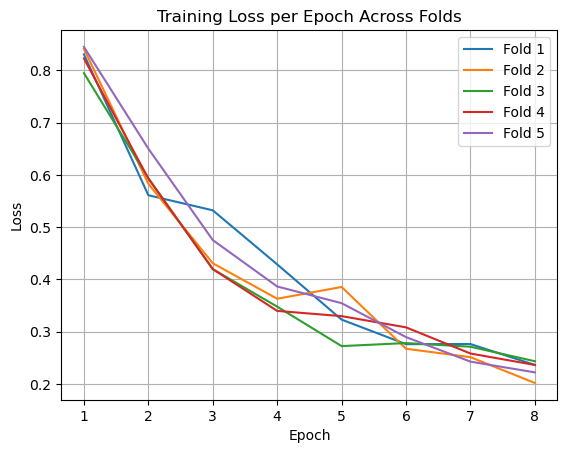

In [21]:
plt.figure()
for i, fold_losses in enumerate(all_fold_losses):
    plt.plot(range(1, num_epochs + 1), fold_losses, label=f'Fold {i+1}')
plt.title('Training Loss per Epoch Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


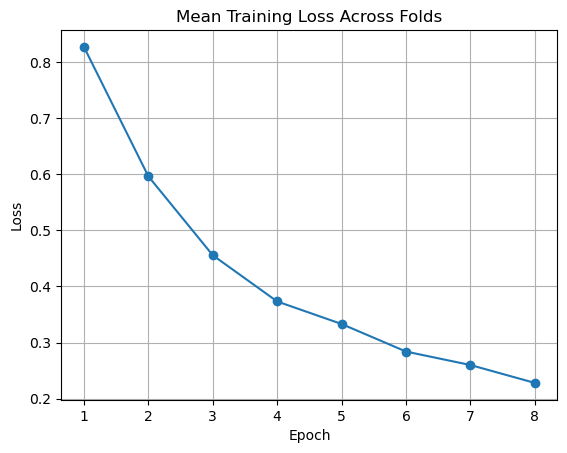

In [18]:
import matplotlib.pyplot as plt
import numpy as np

mean_losses = np.mean(all_fold_losses, axis=0)
mean_accuracies = np.mean(all_fold_accuracies, axis=0)

plt.figure()
plt.plot(range(1, num_epochs + 1), mean_losses, marker='o')
plt.title('Mean Training Loss Across Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


Evaluating Fold 1...
Accuracy for Fold 1: 0.9375


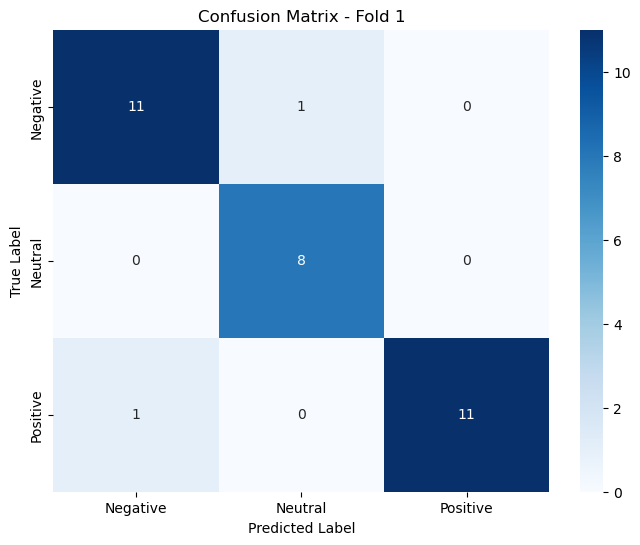


Classification Report for Fold 1:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92        12
     Neutral       0.89      1.00      0.94         8
    Positive       1.00      0.92      0.96        12

    accuracy                           0.94        32
   macro avg       0.94      0.94      0.94        32
weighted avg       0.94      0.94      0.94        32


Evaluating Fold 2...
Accuracy for Fold 2: 0.9697


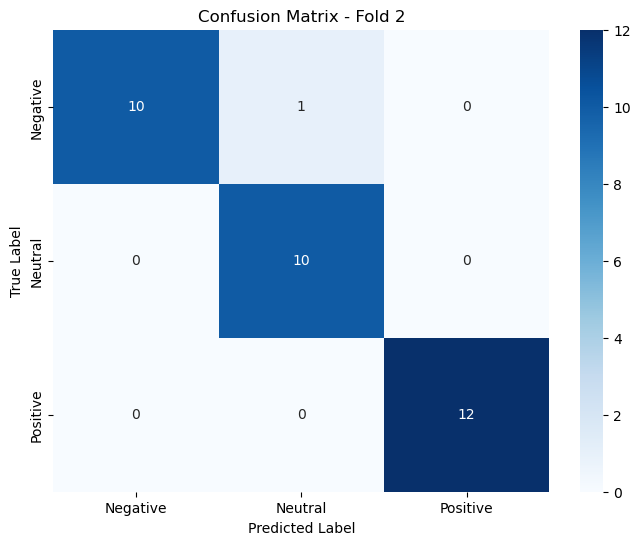


Classification Report for Fold 2:
              precision    recall  f1-score   support

    Negative       1.00      0.91      0.95        11
     Neutral       0.91      1.00      0.95        10
    Positive       1.00      1.00      1.00        12

    accuracy                           0.97        33
   macro avg       0.97      0.97      0.97        33
weighted avg       0.97      0.97      0.97        33


Evaluating Fold 3...
Accuracy for Fold 3: 0.8929


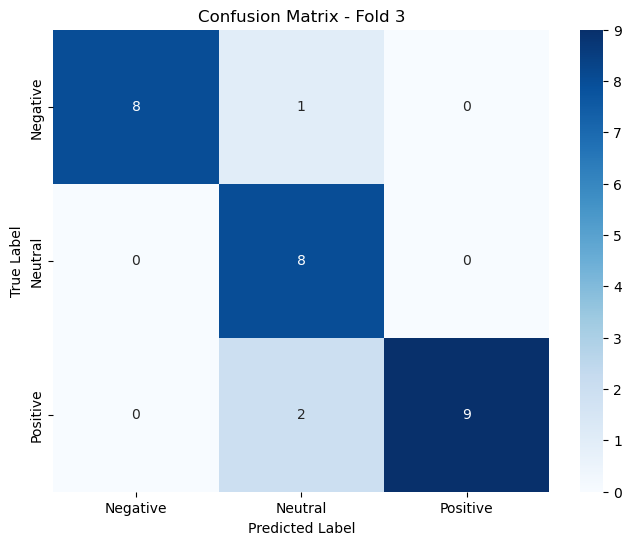


Classification Report for Fold 3:
              precision    recall  f1-score   support

    Negative       1.00      0.89      0.94         9
     Neutral       0.73      1.00      0.84         8
    Positive       1.00      0.82      0.90        11

    accuracy                           0.89        28
   macro avg       0.91      0.90      0.89        28
weighted avg       0.92      0.89      0.90        28


Evaluating Fold 4...
Accuracy for Fold 4: 1.0000


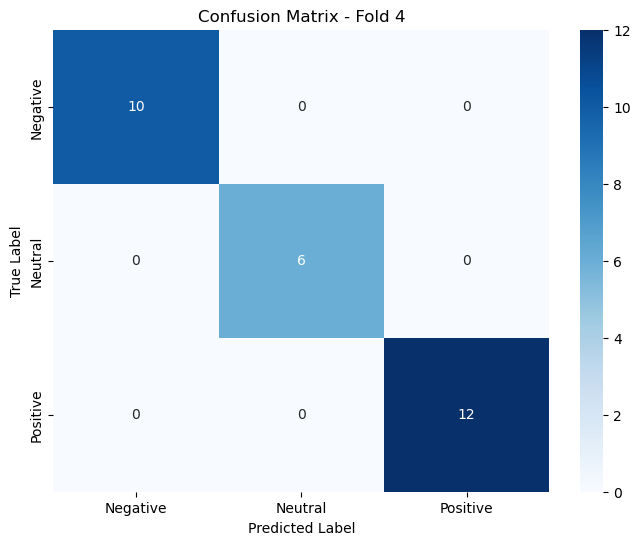


Classification Report for Fold 4:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        10
     Neutral       1.00      1.00      1.00         6
    Positive       1.00      1.00      1.00        12

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28


Evaluating Fold 5...
Accuracy for Fold 5: 0.9667


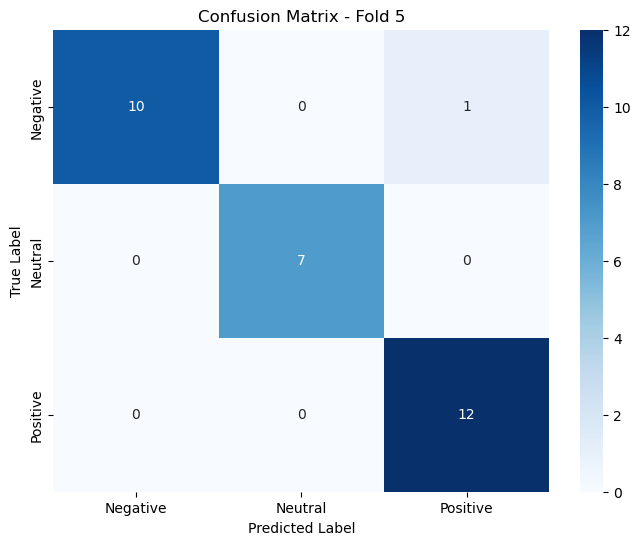


Classification Report for Fold 5:
              precision    recall  f1-score   support

    Negative       1.00      0.91      0.95        11
     Neutral       1.00      1.00      1.00         7
    Positive       0.92      1.00      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Final Results:
Accuracies for each fold: [0.9375, 0.9696969696969697, 0.8928571428571429, 1.0, 0.9666666666666667]
Average Accuracy across 5 folds: 0.9533

Saved prediction dataframe!


In [9]:
misclassified_images_dict = {}
accuracies = []
prediction_records = []

for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}...")
    train_folder = os.path.join(base_data_folder, 'train-test-2', f"train{fold}")
    test_folder = os.path.join(base_data_folder, 'train-test-2', f"test{fold}")
    label_file = os.path.join(base_data_folder, "Validationinfo", "labels.csv")

    df = pd.read_csv(label_file)
    test_df = df[df["Image"].isin(os.listdir(test_folder))]
    X_test, y_test = test_df["Image"].tolist(), test_df["imageCat"].tolist()

    test_dataset = AffectDataset(X_test, y_test, test_folder, transform=data_transforms)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

    model_path = f"../models/{model_name}_fold{fold}.pth"
    model = recognizer.model
    in_features = recognizer.classifier_weights.shape[1]
    model.classifier = nn.Linear(in_features, num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_preds = []
    all_labels = []
    misclassified_images = []
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for batch in test_dataloader:
            images, labels, img_names = batch  # <- Now you get the filenames properly
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            for img_tensor, true_label, pred_label, img_name in zip(images, labels, predicted, img_names):
                prediction_records.append({
                    "image_name": img_name,
                    "true_label_idx": true_label.item(),
                    "true_label_name": class_labels[true_label.item()],
                    "predicted_label_idx": pred_label.item(),
                    "predicted_label_name": class_labels[pred_label.item()],
                    "fold": fold
                })

                if true_label != pred_label:
                    misclassified_images.append((img_name, class_labels[pred_label.item()]))

            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = correct_predictions / total_samples
    accuracies.append(accuracy)
    print(f"Accuracy for Fold {fold}: {accuracy:.4f}")

    misclassified_images_dict[f"Fold {fold}"] = misclassified_images

    cm = confusion_matrix(all_labels, all_preds)
    class_names = ["Negative", "Neutral", "Positive"]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

    print(f"\nClassification Report for Fold {fold}:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Final results
average_accuracy = sum(accuracies) / len(accuracies)
print("\nFinal Results:")
print(f"Accuracies for each fold: {accuracies}")
print(f"Average Accuracy across 5 folds: {average_accuracy:.4f}")

prediction_df = pd.DataFrame(prediction_records)
prediction_df.to_csv("predictions_all_folds.csv", index=False)
print("\nSaved prediction dataframe!")


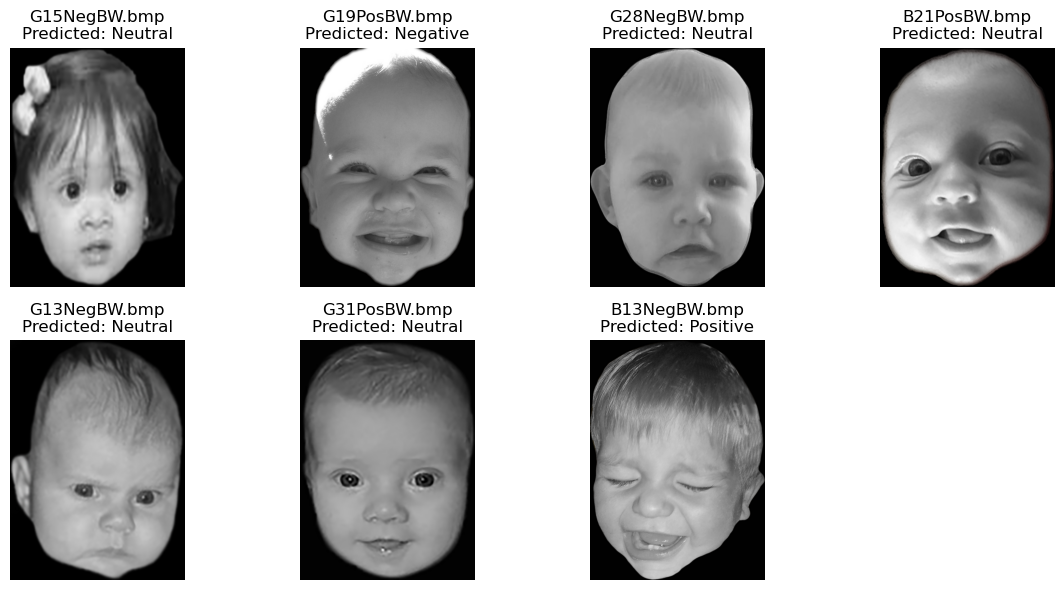

In [10]:
# PLOT MISCLASSIFIED

all_misclassified_images = []

# Loop through each fold and add misclassified images to the list
for fold, images in misclassified_images_dict.items():
    all_misclassified_images.extend(images)

# Create a grid of images (adjust grid size depending on the number of misclassified images)
num_images = len(all_misclassified_images)
cols = min(num_images, 4)  # Show up to 4 images per row (you can adjust this)
rows = (num_images + cols - 1) // cols  # Calculate rows required

# Create the plot grid
plt.figure(figsize=(cols * 3, rows * 3))
for i, (img_name, predicted_label) in enumerate(all_misclassified_images):
    img_path = os.path.join(base_data_folder,'BlackWhite', img_name)  # Get the image path
    
    # Load image with OpenCV
    frame_bgr = cv2.imread(img_path)
    if frame_bgr is None:
        print(f"Image {img_name} not found.")
        continue

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    image = Image.fromarray(frame_rgb)  # Convert to PIL Image

    # Plot image
    plt.subplot(rows, cols, i + 1)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title(f"{img_name}\nPredicted: {predicted_label}")

plt.tight_layout()
plt.show()

In [11]:
prediction_df = pd.DataFrame(prediction_records)
prediction_df.to_csv("../data/predictions_all_folds.csv", index=False)
prediction_df

,image_name,true_label_idx,true_label_name,predicted_label_idx,predicted_label_name,fold
0,B3NegBw.bmp,0,Negative,0,Negative,1
1,B3PosBW.bmp,2,Positive,2,Positive,1
2,B7NegBW.bmp,0,Negative,0,Negative,1
3,B7NeuBW.bmp,1,Neutral,1,Neutral,1
4,B7PosBW.bmp,2,Positive,2,Positive,1
...,...,...,...,...,...,...
146,G33PosBW.bmp,2,Positive,2,Positive,5
147,G33NegBW.bmp,0,Negative,0,Negative,5
148,G34NegBW.bmp,0,Negative,0,Negative,5
149,G34NeuBW.bmp,1,Neutral,1,Neutral,5


In [12]:
import torch.nn.functional as F

def generate_saliency_map(model, image_tensor, label_idx=None):
    model.eval()
    image_tensor.requires_grad_()

    output = model(image_tensor)
    if label_idx is None:
        label_idx = output.argmax().item()

    score = output[0, label_idx]
    model.zero_grad()
    score.backward()

    saliency = image_tensor.grad.data.abs().squeeze().cpu()
    saliency, _ = torch.max(saliency, dim=0)

    return saliency.numpy()

def generate_smooth_grad(model, image_tensor, label_idx=None, stdev_spread=0.05, num_samples=100):
    model.eval()

    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)  # [1, 3, H, W]

    stdev = stdev_spread * (image_tensor.max() - image_tensor.min())
    smooth_grad = torch.zeros_like(image_tensor)

    for _ in range(num_samples):
        noise = torch.randn_like(image_tensor) * stdev
        noisy_image = (image_tensor + noise).requires_grad_()

        output = model(noisy_image)
        if label_idx is None:
            label_idx = output.argmax().item()

        score = output[0, label_idx]
        model.zero_grad()
        score.backward()

        grad = noisy_image.grad.abs()
        smooth_grad += grad

    smooth_grad /= num_samples
    smooth_grad = smooth_grad.squeeze().cpu()
    smooth_grad, _ = torch.max(smooth_grad, dim=0)

    smooth_grad = smooth_grad.numpy()
    smooth_grad = (smooth_grad - np.min(smooth_grad)) / (np.max(smooth_grad) - np.min(smooth_grad) + 1e-8)

    smooth_grad = smooth_grad ** 0.5  # Gamma < 1 brightens

    return smooth_grad

def show_saliency_on_image(image_tensor, saliency_map, title="Saliency Map"):
    image_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    image_np = np.clip(image_np, 0, 1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(image_np)
    plt.imshow(saliency_map, cmap='jet', alpha=0.5)  # Use "jet", and more vivid blending
    plt.axis("off")
    plt.title(title)

    plt.tight_layout()
    plt.show()

In [13]:
def visualize_misclassified_saliency(model, misclassified_list, images_folder, num_images=10, smooth=False):
    model.eval()
    count = 0
    plt.figure(figsize=(12, num_images * 2.5))

    for img_name, predicted_label in misclassified_list:
        if count >= num_images:
            break

        img_path = os.path.join(images_folder, img_name)
        frame_bgr = cv2.imread(img_path)
        if frame_bgr is None:
            print(f"Image {img_name} not found.")
            continue

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(frame_rgb)
        image_tensor = data_transforms(image_pil).unsqueeze(0).to(device)

        if smooth:
            saliency_map = generate_smooth_grad(model, image_tensor.clone())
            title = f"SmoothGrad - Predicted: {predicted_label}"
        else:
            saliency_map = generate_saliency_map(model, image_tensor.clone())
            title = f"Saliency - Predicted: {predicted_label}"

        image_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        image_np = (image_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        image_np = np.clip(image_np, 0, 1)

        plt.subplot(num_images, 2, count * 2 + 1)
        plt.imshow(image_np)
        plt.axis("off")
        plt.title("Original")

        plt.subplot(num_images, 2, count * 2 + 2)
        plt.imshow(image_np)
        plt.imshow(saliency_map, cmap='jet', alpha=0.4)
        plt.axis("off")
        plt.title(title)

        count += 1

    plt.tight_layout()
    plt.show()


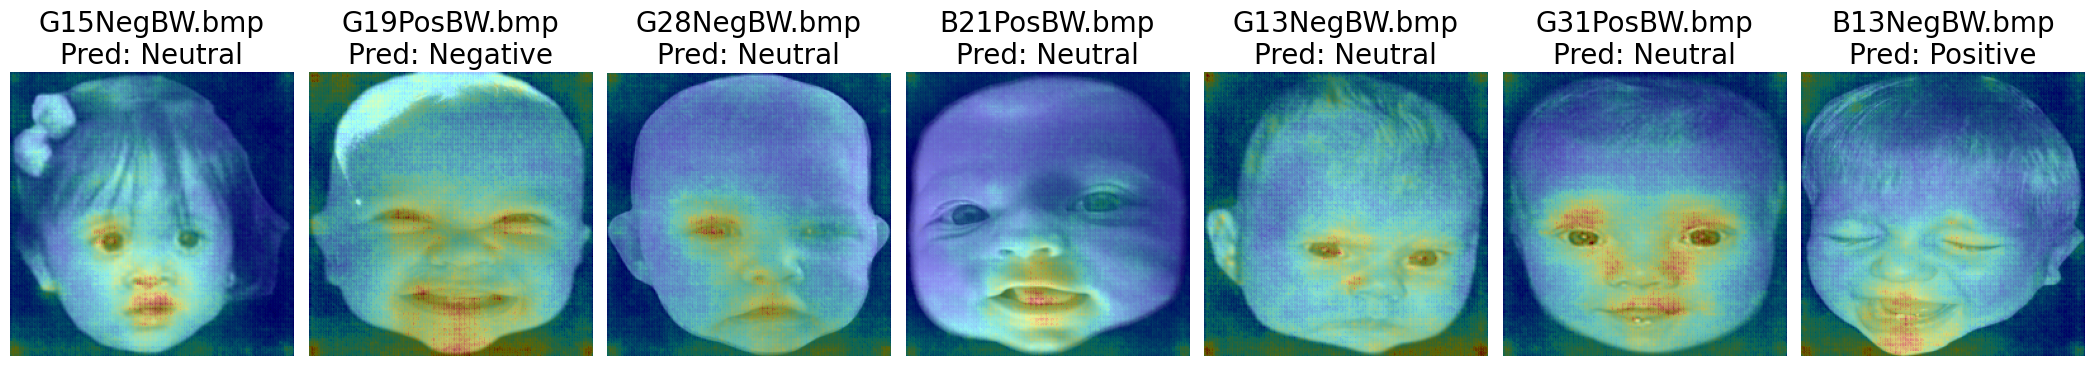

In [14]:
def visualize_misclassified_saliency(model, misclassified_list, images_folder, num_images=10, smooth=False):
    model.eval()
    count = 0
    plt.figure(figsize=(num_images * 3, 4))  # Wide layout (one row)

    for idx, (img_name, predicted_label) in enumerate(misclassified_list):
        if count >= num_images:
            break

        img_path = os.path.join(images_folder, img_name)
        frame_bgr = cv2.imread(img_path)
        if frame_bgr is None:
            print(f"Image {img_name} not found.")
            continue

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(frame_rgb)
        image_tensor = data_transforms(image_pil).unsqueeze(0).to(device)

        if smooth:
            saliency_map = generate_smooth_grad(model, image_tensor.clone())
        else:
            saliency_map = generate_saliency_map(model, image_tensor.clone())

        # Denormalize the image for visualization
        image_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        image_np = (image_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        image_np = np.clip(image_np, 0, 1)

        # Plot
        plt.subplot(1, num_images, count + 1)
        plt.imshow(image_np)
        plt.imshow(saliency_map, cmap='jet', alpha=0.4)
        plt.axis("off")
        plt.title(f"{img_name}\nPred: {predicted_label}", fontsize=20)

        count += 1

    plt.tight_layout()
    plt.show()


visualize_misclassified_saliency(
    model,
    misclassified_list=all_misclassified_images,  # from your previous code
    images_folder=os.path.join(base_data_folder, 'BlackWhite'),  # adjust if needed
    num_images=10,
    smooth=True  
)


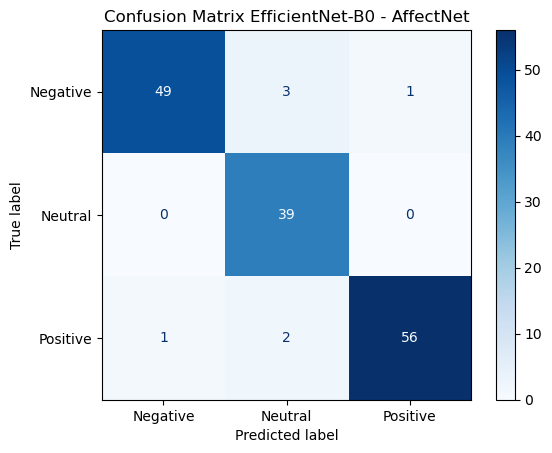

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Extract true and predicted labels from the dataframe
y_true = prediction_df['true_label_idx']
y_pred = prediction_df['predicted_label_idx']

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Define class names (in correct order by index)
class_names = ["Negative", "Neutral", "Positive"]

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix EfficientNet-B0 - AffectNet')
plt.show()


In [16]:
correct_predictions = (prediction_df['true_label_idx'] == prediction_df['predicted_label_idx']).sum()
total_predictions = len(prediction_df)
overall_accuracy = correct_predictions / total_predictions
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# 2. Calculate per-class accuracies
class_accuracies = {}

for class_idx in prediction_df['true_label_idx'].unique():
    # Filter rows where true label == class_idx
    class_rows = prediction_df[prediction_df['true_label_idx'] == class_idx]
    class_correct = (class_rows['true_label_idx'] == class_rows['predicted_label_idx']).sum()
    class_total = len(class_rows)
    class_accuracy = class_correct / class_total
    class_accuracies[class_idx] = class_accuracy

# Map class index to class name if you have a dictionary
class_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Print
print("\nPer-Class Accuracies:")
for idx, acc in class_accuracies.items():
    print(f"{class_labels[idx]}: {acc:.4f}")

Overall Accuracy: 0.9536

Per-Class Accuracies:
Negative: 0.9245
Positive: 0.9492
Neutral: 1.0000


In [17]:
y_true = prediction_df['true_label_idx']
y_pred = prediction_df['predicted_label_idx']

# 1. Overall accuracy
correct_predictions = (y_true == y_pred).sum()
total_predictions = len(prediction_df)
overall_accuracy = correct_predictions / total_predictions
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# 2. Classification report
class_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}

report = classification_report(
    y_true, y_pred,
    target_names=[class_labels[i] for i in sorted(class_labels.keys())],
    digits=4  # format nicely to 4 decimals
)

print("\nClassification Report:")
print(report)


Overall Accuracy: 0.9536

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9800    0.9245    0.9515        53
     Neutral     0.8864    1.0000    0.9398        39
    Positive     0.9825    0.9492    0.9655        59

    accuracy                         0.9536       151
   macro avg     0.9496    0.9579    0.9522       151
weighted avg     0.9568    0.9536    0.9539       151

